# HW1：从零开始构建三层神经网络分类器

## 任务目标

本实验使用 `NumPy` 手工实现多层感知机（MLP），在 Fashion-MNIST 数据集上完成 10 类服饰图像分类。

## 本 notebook 包含的内容

- 数据加载与预处理
- 超参数搜索说明与已有搜索结果
- 最终模型训练曲线
- 测试集准确率与混淆矩阵
- 第一层权重可视化
- 错例分析与原因讨论


In [29]:
# 开启自动重载，确保 src 下的代码修改能实时生效
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.data_utils import get_preprocessed_data, BatchIterator
from src.model import MLP
from src.loss import CrossEntropyLoss
from src.optimizers import SGD, ExponentialScheduler
from src.train import train_model
from src.search import run_grid_search
from src.test import (
    load_trained_model,
    evaluate_and_plot_confusion_matrix,
    visualize_first_layer_weights,
    plot_misclassified_samples,
    summarize_top_confusions
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. 数据加载与预处理

训练集与验证集按照 `8:2` 划分。输入图像被展平成 `784` 维向量并归一化到 `[0, 1]`，标签使用 one-hot 编码，以便后续交叉熵损失函数计算。

In [13]:
print("加载并划分数据集...")
train_data, val_data, test_data = get_preprocessed_data(val_split=0.2)

X_train, y_train_oh, y_train_labels = train_data
X_val, y_val_oh, y_val_labels = val_data
X_test, y_test_oh, y_test_labels = test_data

print(f"训练集维度: X={X_train.shape}, Y={y_train_oh.shape}")
print(f"验证集维度: X={X_val.shape}, Y={y_val_oh.shape}")
print(f"测试集维度: X={X_test.shape}, Y={y_test_oh.shape}")

加载并划分数据集...
训练集维度: X=(48000, 784), Y=(48000, 10)
验证集维度: X=(12000, 784), Y=(12000, 10)
测试集维度: X=(10000, 784), Y=(10000, 10)


## 2. 超参数搜索

搜索空间覆盖隐藏层维度、学习率、L2 正则强度、batch size 和激活函数。为了避免每次打开 notebook 都重新跑完整网格搜索，这里默认复用已有搜索报告；如果需要完整复现，可将 `RUN_GRID_SEARCH` 改为 `True`。

In [ ]:
RUN_GRID_SEARCH = False

param_grid = {
    'hidden_dims': [[128, 64], [256, 128]],
    'learning_rate': [0.1, 0.05, 0.01],
    'weight_decay': [1e-4, 0.0],
    'batch_size': [64, 128],
    'activation': ['relu', 'sigmoid', 'tanh'],
    'dropout_rate': [0.0, 0.2]   # 加入搜索，对应 src/search.py 的 config.get
}

if RUN_GRID_SEARCH:
    sorted_results, report_file = run_grid_search(
        X_train, y_train_oh, X_val, y_val_oh,
        param_grid=param_grid,
        max_epochs=8,
        patience=2
    )
    print(f"网格搜索最优验证集准确率: {sorted_results[0]['val_acc']:.4f}")
    print(f"对应的最优参数: {sorted_results[0]['config']}")
else:
    # 自动查找 logs/ 下最新的搜索报告，无需每次手动更新文件名
    import glob
    _reports = sorted(glob.glob('./logs/report_*.txt'), key=os.path.getmtime)
    if not _reports:
        raise FileNotFoundError("未找到搜索报告，请将 RUN_GRID_SEARCH 设为 True 先运行一次网格搜索。")
    report_file = _reports[-1]
    print(f"已跳过网格搜索，复用已有搜索报告: {report_file}")


144 trials to run ...
[1/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.0}
[2/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.2}
[3/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'sigmoid', 'dropout_rate': 0.0}
[4/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'sigmoid', 'dropout_rate': 0.2}
[5/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'tanh', 'dropout_rate': 0.0}
[6/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'tanh', 'dropout_rate': 0.2}
[7/144] {'hidden_dims': [128, 64], 'learning_rate': 0.1, 'weight_decay': 0.0001, 'batch_size': 128, 'activation': 'relu'

In [15]:
top_results = []
with open(report_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line.startswith('Top '):
            left, config_part = line.split(' | 配置: ')
            rank_part, acc_part = left.split(' | Acc: ')
            top_results.append({
                'rank': rank_part,
                'val_acc': float(acc_part),
                'config': ast.literal_eval(config_part)
            })

print('网格搜索 Top-5 结果:')
for item in top_results[:5]:
    print(f"- {item['rank']} | val_acc={item['val_acc']:.4f} | config={item['config']}")

网格搜索 Top-5 结果:
- Top 1 | val_acc=0.8862 | config={'hidden_dims': [256, 128], 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.0}
- Top 2 | val_acc=0.8862 | config={'hidden_dims': [256, 128], 'learning_rate': 0.01, 'weight_decay': 0.0, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.0}
- Top 3 | val_acc=0.8850 | config={'hidden_dims': [128, 64], 'learning_rate': 0.05, 'weight_decay': 0.0, 'batch_size': 128, 'activation': 'tanh', 'dropout_rate': 0.0}
- Top 4 | val_acc=0.8829 | config={'hidden_dims': [256, 128], 'learning_rate': 0.01, 'weight_decay': 0.0, 'batch_size': 64, 'activation': 'tanh', 'dropout_rate': 0.0}
- Top 5 | val_acc=0.8824 | config={'hidden_dims': [128, 64], 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.0}


从已有搜索结果可以看到，`[256, 128] + relu + lr=0.01 + weight_decay=0.0001 + dropout=0.0 + batch_size=64` 的组合取得了最高验证集准确率（0.8862），因此下面使用该组合训练最终模型。

## 3. 最终模型训练

最终模型使用三层结构（输入层 + 两层隐藏层 + 输出层），激活函数为 ReLU，不使用 Dropout（网格搜索结果显示无 Dropout 的配置表现更优）。训练最多进行 30 轮，早停机制（patience=5，min_delta=1e-4）在验证集准确率连续 5 轮无显著提升时自动终止，并保存验证集表现最佳的模型权重。训练过程中记录训练集与验证集的 loss 及 accuracy 曲线。

使用最优参数启动最终训练: {'hidden_dims': [256, 128], 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.0}
training 30 epochs ...
epoch 01/30 [0.5s] lr=0.01000  train loss=0.5734 acc=0.7989  val loss=0.4411 acc=0.8411
  -> saved (val acc 0.8411)
epoch 02/30 [0.5s] lr=0.01000  train loss=0.4042 acc=0.8567  val loss=0.3934 acc=0.8591
  -> saved (val acc 0.8591)
epoch 03/30 [0.5s] lr=0.01000  train loss=0.3620 acc=0.8688  val loss=0.3865 acc=0.8640
  -> saved (val acc 0.8640)
epoch 04/30 [0.5s] lr=0.01000  train loss=0.3360 acc=0.8779  val loss=0.4212 acc=0.8479
epoch 05/30 [0.5s] lr=0.00900  train loss=0.3184 acc=0.8830  val loss=0.3349 acc=0.8761
  -> saved (val acc 0.8761)
epoch 06/30 [0.5s] lr=0.00900  train loss=0.2973 acc=0.8904  val loss=0.3289 acc=0.8824
  -> saved (val acc 0.8824)
epoch 07/30 [0.5s] lr=0.00900  train loss=0.2860 acc=0.8948  val loss=0.3166 acc=0.8872
  -> saved (val acc 0.8872)
epoch 08/30 [0.5s] lr=0.00900  train loss=0

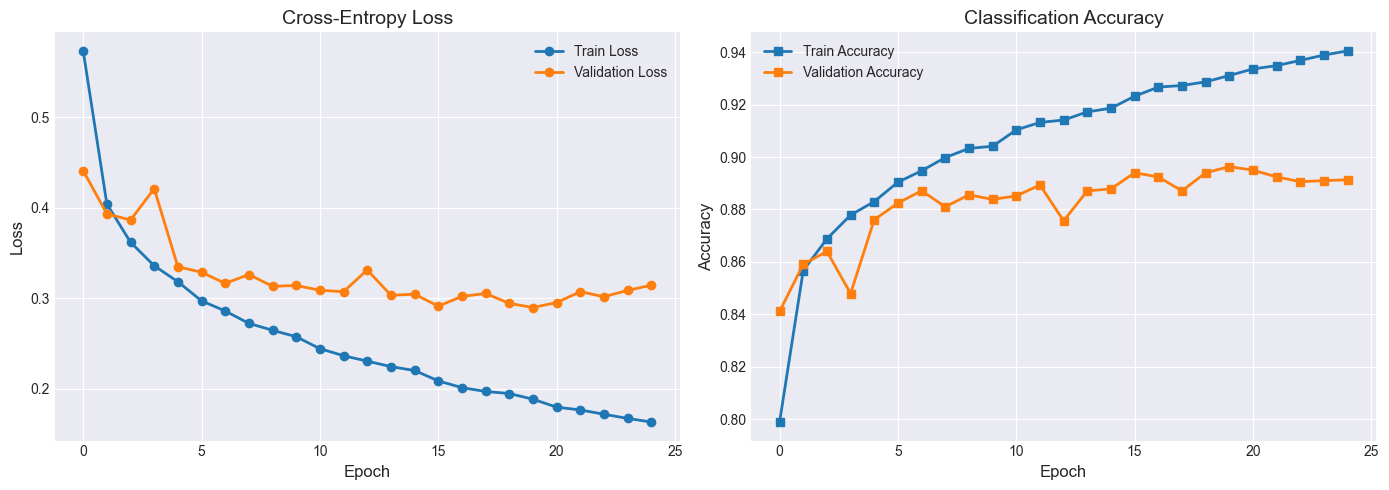

In [31]:
BEST_PARAMS = {
    'hidden_dims': [256, 128],
    'learning_rate': 0.01,
    'weight_decay': 0.0001,
    'batch_size': 64,
    'activation': 'relu',
    'dropout_rate': 0.0
}

print(f"使用最优参数启动最终训练: {BEST_PARAMS}")

train_loader = BatchIterator(X_train, y_train_oh, batch_size=BEST_PARAMS['batch_size'], shuffle=True)
val_loader   = BatchIterator(X_val,   y_val_oh,   batch_size=BEST_PARAMS['batch_size'], shuffle=False)
# test_loader 在第 4 节评估时再创建，此处无需提前定义

best_model = MLP(
    input_dim=784,
    hidden_dims=BEST_PARAMS['hidden_dims'],
    num_classes=10,
    activation=BEST_PARAMS['activation'],
    dropout_rate=BEST_PARAMS['dropout_rate']
)
criterion = CrossEntropyLoss()
optimizer = SGD(
    model=best_model,
    lr=BEST_PARAMS['learning_rate'],
    momentum=0.9,
    weight_decay=BEST_PARAMS['weight_decay']
)
scheduler = ExponentialScheduler(optimizer, decay_rate=0.9, decay_steps=5)

final_save_path = './models/final_best_model.pkl'
history = train_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=30,
    scheduler=scheduler,
    save_path=final_save_path,
    early_stopping_patience=5,
    min_delta=1e-4
)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
plt.title('Cross-Entropy Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', marker='s', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2)
plt.title('Classification Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
best_epoch    = int(np.argmax(history['val_acc'])) + 1
best_val_acc  = float(np.max(history['val_acc']))
final_train_acc = float(history['train_acc'][-1])
final_val_acc   = float(history['val_acc'][-1])

print(f'best val acc: {best_val_acc:.4f} (epoch {best_epoch})')
print(f'final epoch  — train: {final_train_acc:.4f}, val: {final_val_acc:.4f}')


best val acc: 0.8963 (epoch 20)
final epoch  — train: 0.9405, val: 0.8913


## 4. 测试集评估与可视化

下面加载保存的最佳权重，在独立测试集上计算准确率，并展示混淆矩阵和第一层权重可视化结果。

test  loss=0.3205  acc=0.8874


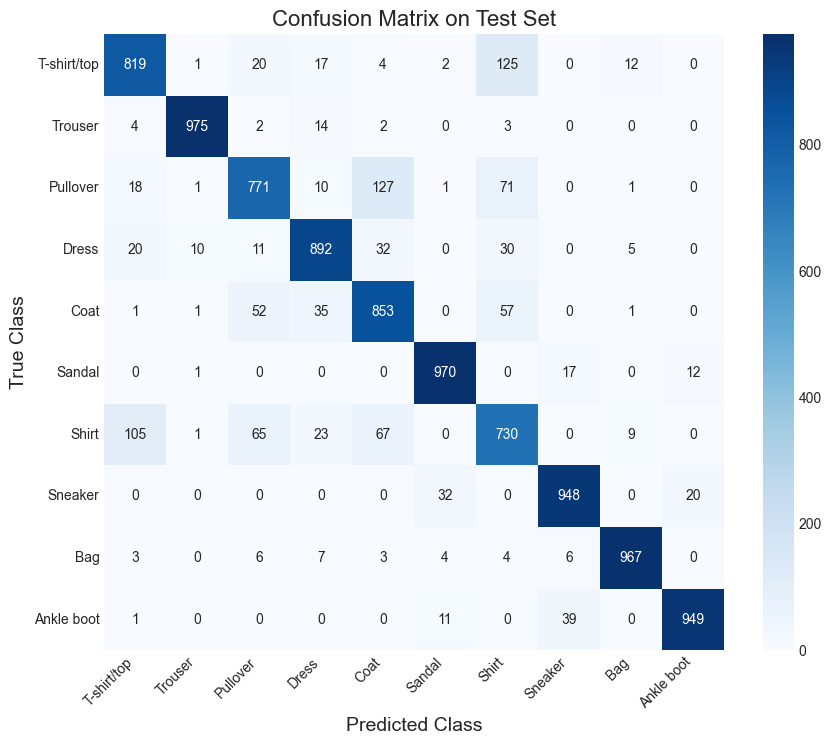

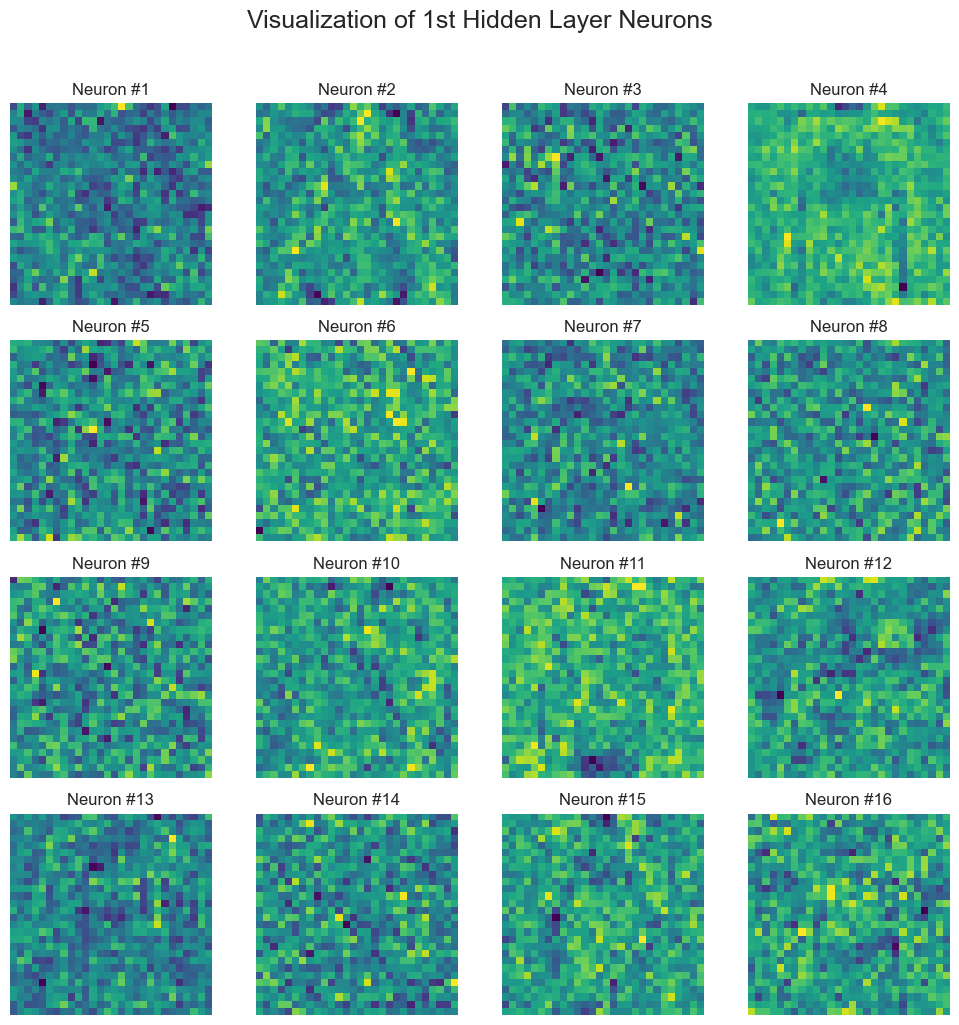

In [34]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# BEST_PARAMS 已包含所有加载所需字段，直接复用，避免重复定义 BEST_CONFIG
BEST_MODEL_PATH = './models/final_best_model.pkl'

test_loader  = BatchIterator(X_test, y_test_oh, batch_size=BEST_PARAMS['batch_size'], shuffle=False)
loaded_model = load_trained_model(model_path=BEST_MODEL_PATH, config=BEST_PARAMS)
criterion    = CrossEntropyLoss()

test_acc, y_pred_labels, cm = evaluate_and_plot_confusion_matrix(
    model=loaded_model,
    test_loader=test_loader,
    criterion=criterion,
    y_test_labels=y_test_labels,
    return_predictions=True,
    class_names=CLASS_NAMES
)

visualize_first_layer_weights(model=loaded_model, num_neurons_to_show=16)


In [35]:
print(f'test acc: {test_acc:.4f}')


test acc: 0.8874


## 权重可视化与空间模式分析

第一隐藏层权重矩阵形状为 (784, 256)，将每列还原为 28×28 图像可以观察每个神经元的空间偏好。以下以前 16 个神经元为例进行讨论。

**整体特征**

所有神经元的权重图均呈现出分散的高低权重像素交错分布，整体噪声感较强，缺少清晰的块状边缘结构。这与本次训练正则化强度极低（weight_decay=1e-4, dropout=0.0）有关：1e-4 的权重衰减对权重幅度的约束十分有限，MLP 仍然倾向于让权重分散到大量像素上，而非集中到少数有区分力的感受野，导致可视化结果较难解读出明确的语义。

**具体模式**

- **孤立高激活锚点型**：Neuron #2（上方）、#3（左上方）、#5（左侧中部）、#16（左侧中部）在整体蓝绿色背景中均出现清晰孤立的高亮黄色像素点，可能对应训练集中特定类别在固定坐标频繁出现的纹理锚点，但因孤立性强、不成连续结构而泛化能力有限；其中 #5 同时伴有多处深紫色低权重像素，高低权重并存，结构最为复杂。

- **均匀分散型**：Neuron #8、#10 以均匀蓝绿色为主，无显著高亮或暗区聚集，权重散布全图，是最难解读语义的一类。Neuron #4、#6、#11 的背景色调偏向鲜亮的黄绿色，整体色彩明亮，与其他神经元的蓝绿背景不同。

- **整体偏暗型**：Neuron #1、#7、#13 的背景整体呈深蓝/蓝紫色，全局权重幅度系统性偏低，是 16 个神经元中整体色调最暗的一组，暗示对较大范围像素区域的广泛抑制响应；Neuron #3、#12 也散布着较多深紫色低权重像素，但暗点相对分散，未形成连片聚集。

**结论**

在极弱正则化约束下，第一层权重未能收敛到具有清晰空间语义的检测器，整体停留在分散的统计相关模式。这从侧面说明：在全连接 MLP 中，适当加大权重衰减或引入 Dropout 有助于迫使每个神经元聚焦于更少、更有意义的输入维度，从而产生更可解释的权重可视化结果。

## 5. 错例分析


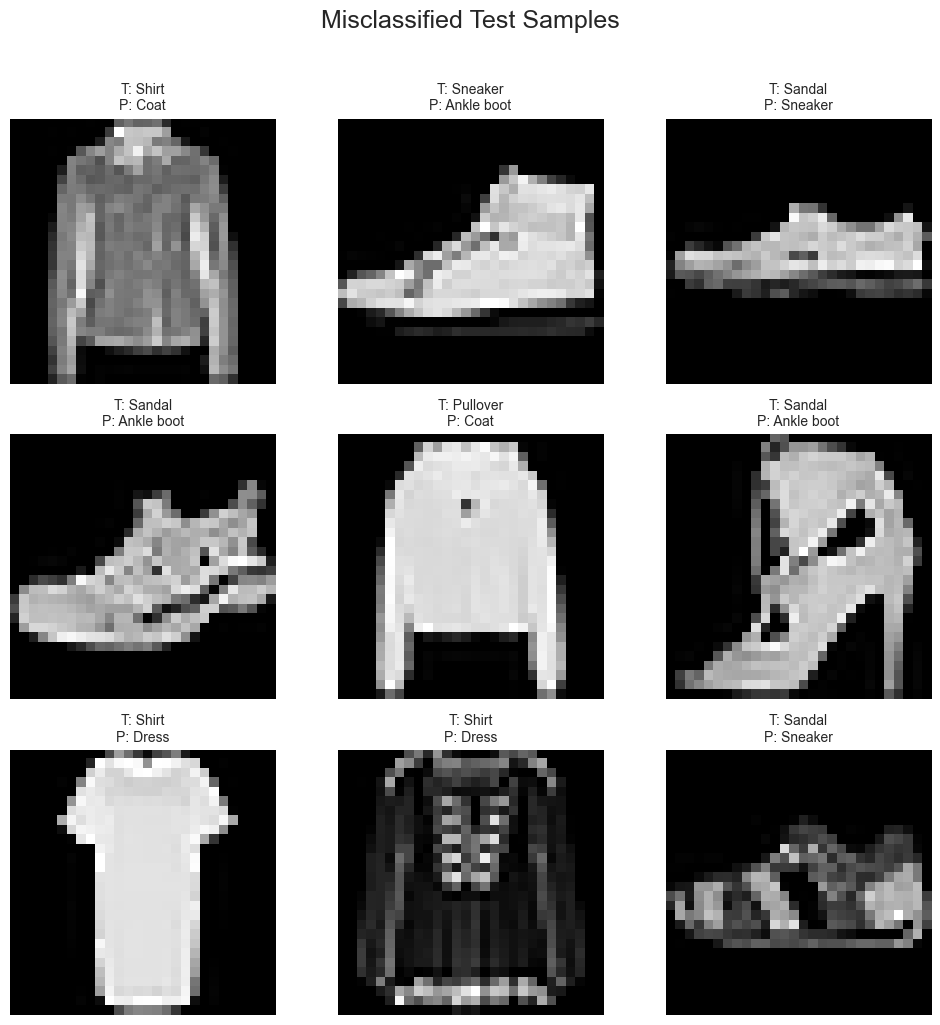

misclassified: 1126 / 10000 (11.3%)
top confusion pairs:
  Pullover        -> Coat           : 127
  T-shirt/top     -> Shirt          : 125
  Shirt           -> T-shirt/top    : 105
  Pullover        -> Shirt          : 71
  Shirt           -> Coat           : 67


In [36]:
total_errors = int(np.sum(y_test_labels != y_pred_labels))

shown_idx = plot_misclassified_samples(
    X_test=X_test,
    y_true_labels=y_test_labels,
    y_pred_labels=y_pred_labels,
    class_names=CLASS_NAMES,
    num_samples=9
)

print(f'misclassified: {total_errors} / {len(y_test_labels)} ({total_errors / len(y_test_labels) * 100:.1f}%)')

print('top confusion pairs:')
for item in summarize_top_confusions(y_test_labels, y_pred_labels, CLASS_NAMES, top_k=5):
    print(f"  {item['true_name']:15s} -> {item['pred_name']:15s}: {item['count']}")


## 错例分析

模型在测试集上共误分类 **1126 / 10000（11.3%）** 张图像。下表为混淆矩阵中 Top-5 混淆对：

| 真实类别 | 预测类别 | 错误数 |
|---|---|---|
| Pullover | Coat | 127 |
| T-shirt/top | Shirt | 125 |
| Shirt | T-shirt/top | 105 |
| Pullover | Shirt | 71 |
| Shirt | Coat | 67 |

Top-5 全部集中于上装四类（T-shirt/top、Shirt、Pullover、Coat），合计 495 例，占总误分类数的 **44%**。以下结合随机抽取的 9 个错例，对主要混淆模式进行分析。

**上装类别互混（占误分类主体）**

- **Pullover → Coat**（最多，127 例）：套头衫与外套的核心区别在于领口结构（圆领 vs 翻领/开襟）和袖管宽度比例。在 28×28 灰度图中，这些细节往往压缩至 1–2 个像素宽的灰度过渡，几乎无法被全连接层可靠感知。版型宽大或颜色偏深的套头衫尤其容易与轮廓相近的外套混淆。

- **T-shirt/top ↔ Shirt 双向混淆**（125 + 105 = 230 例）：T 恤与衬衫的整体廓形几乎完全一致——均为上宽下窄的矩形主体区域。衬衫的关键辨别特征（门襟线、纽扣排列、领口细节）在低分辨率灰度图中极难察觉，导致两类之间发生大量对称性互混。领口偏平的 T 恤容易被判为衬衫，而轮廓宽松的衬衫则容易被判为 T 恤。

- **Pullover → Shirt**（71 例）：低领或 V 领套头衫的领口较平整，整体轮廓与平口衬衫接近，模型在无法感知材质和领口细节的情况下产生混淆。

- **Shirt → Coat**（67 例）：版型宽大的夹克式衬衫肩线外扩、下摆较宽，在像素分布上与外套的廓形相近，被误判为外套。

**随机错例中的采样分布与共性规律**

本次随机抽取的 9 张错例中，**5 张为鞋类混淆**（Sandal→Sneaker、Sandal→Ankle boot、Sneaker→Ankle boot），**4 张为上装混淆**（Shirt→Coat、Pullover→Coat、Shirt→Dress）。

两类错误的成因不同：

- **鞋类混淆**：Sandal 的镂空结构和细带特征在 28×28 灰度图中被压缩至几个像素，侧视剪影与同高度的运动鞋或短靴几乎无法区分；高帮运动鞋覆盖脚踝，侧视轮廓高度与 Ankle boot 相近，极易混淆。
- **上装混淆**：领口细节、开襟线、袖型等关键辨别特征在低分辨率下被压缩，整体廓形相近的类别之间发生混淆，与 Top-5 分析一致。

**总结**

本次运行的主要系统性误差集中于上装类别内部（Top-5 全为上装混淆），根本原因在于 MLP 缺乏局部特征提取机制，无法捕捉领口形状、开襟方式等细节。引入卷积结构（CNN）或注意力机制将是改善此类混淆的最直接方向。

## 6. 结论

综合训练曲线、测试集结果、混淆矩阵和错例分析，可以得到以下结论：

1. 从零实现的 MLP 能够在 Fashion-MNIST 上稳定达到较高准确率（测试集 88.74%，最优验证集 89.63%），证明前向传播、反向传播、交叉熵、SGD+Momentum 和学习率衰减模块工作正常。
2. 轮廓差异明显的类别（如 `Trouser`、`Bag`、`Ankle boot`）更容易区分；上装类别（T-shirt/top、Shirt、Pullover、Coat）之间由于在 28×28 灰度图中廓形高度相似，是主要错误来源，占总误分类数的 44%。
3. 第一层权重在极弱正则化（weight_decay=1e-4）下呈现出分散的统计相关模式，尚未形成具有清晰空间语义的局部检测器。
4. 如果继续优化，可以尝试引入卷积结构（CNN）以提取局部特征、加大正则化强度、或通过更精细的超参数搜索进一步降低上装类别之间的混淆。